In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

In [63]:
# ── 1. TOSS IMPACT ───────────────────────────────────────────
matches['toss_won_match'] = matches['toss_winner'] == matches['winner']
toss_impact = matches['toss_won_match'].value_counts(normalize=True) * 100
print("Toss winner won the match:", round(toss_impact[True], 1), "%")

decision_impact = matches.groupby('toss_decision')['toss_won_match'].mean() * 100
print("\nWin % by toss decision:")
print(decision_impact.round(1))

Toss winner won the match: 50.6 %

Win % by toss decision:
toss_decision
bat      45.3
field    53.6
Name: toss_won_match, dtype: float64


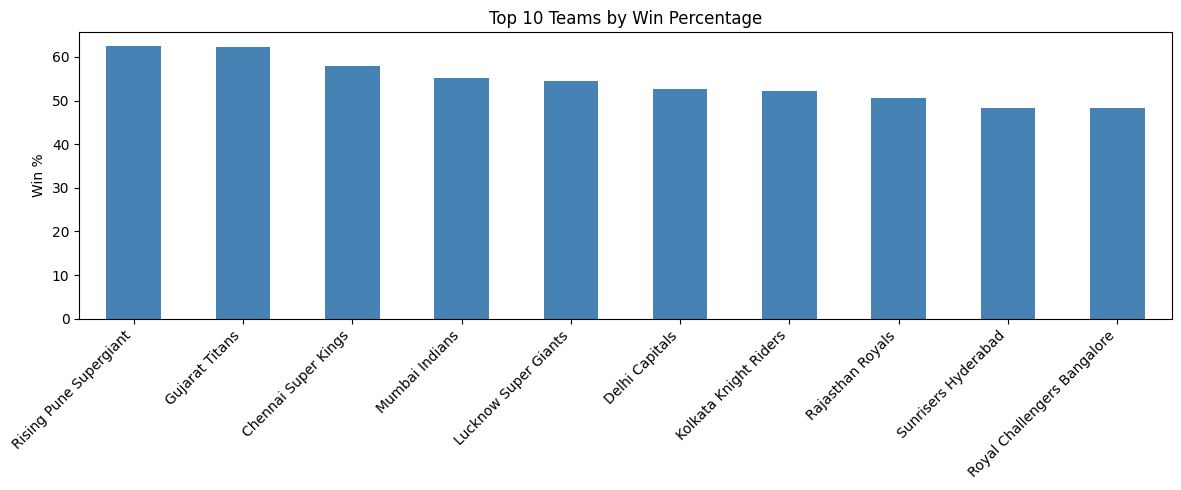

In [64]:
# ── 2. TEAM WIN PERCENTAGE ───────────────────────────────────
total_matches = pd.concat([matches['team1'], matches['team2']]).value_counts()
total_wins = matches['winner'].value_counts()
win_pct = (total_wins / total_matches * 100).dropna().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
win_pct.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Teams by Win Percentage')
plt.ylabel('Win %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('team_win_pct.png')
plt.show()

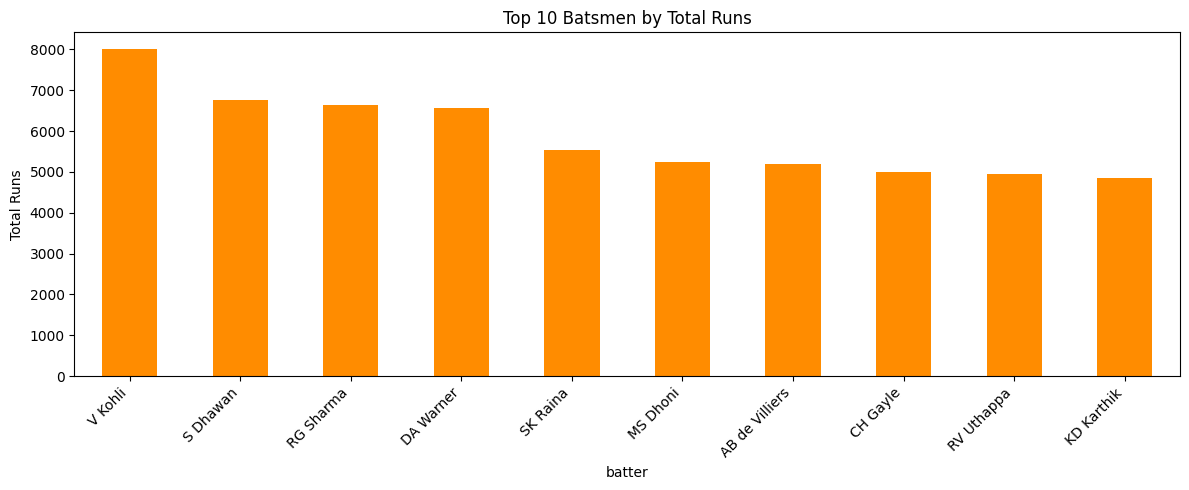

In [65]:
# ── 3. TOP 10 BATSMEN ────────────────────────────────────────
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_batsmen.plot(kind='bar', color='darkorange')
plt.title('Top 10 Batsmen by Total Runs')
plt.ylabel('Total Runs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_batsmen.png')
plt.show()

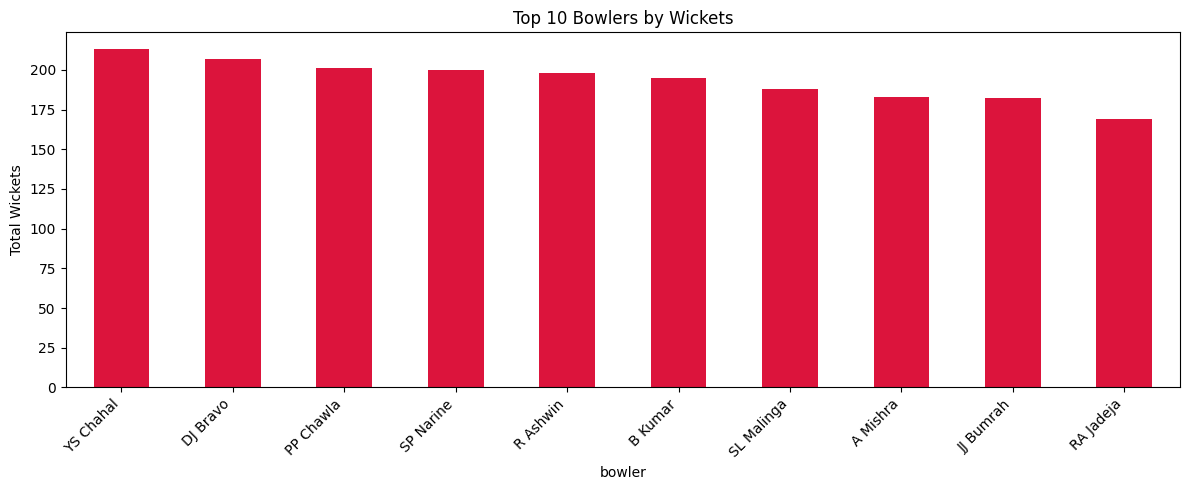

In [66]:
# ── 4. TOP 10 BOWLERS ────────────────────────────────────────
wickets = deliveries[deliveries['is_wicket'] == 1]
top_bowlers = wickets.groupby('bowler')['is_wicket'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_bowlers.plot(kind='bar', color='crimson')
plt.title('Top 10 Bowlers by Wickets')
plt.ylabel('Total Wickets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_bowlers.png')
plt.show()

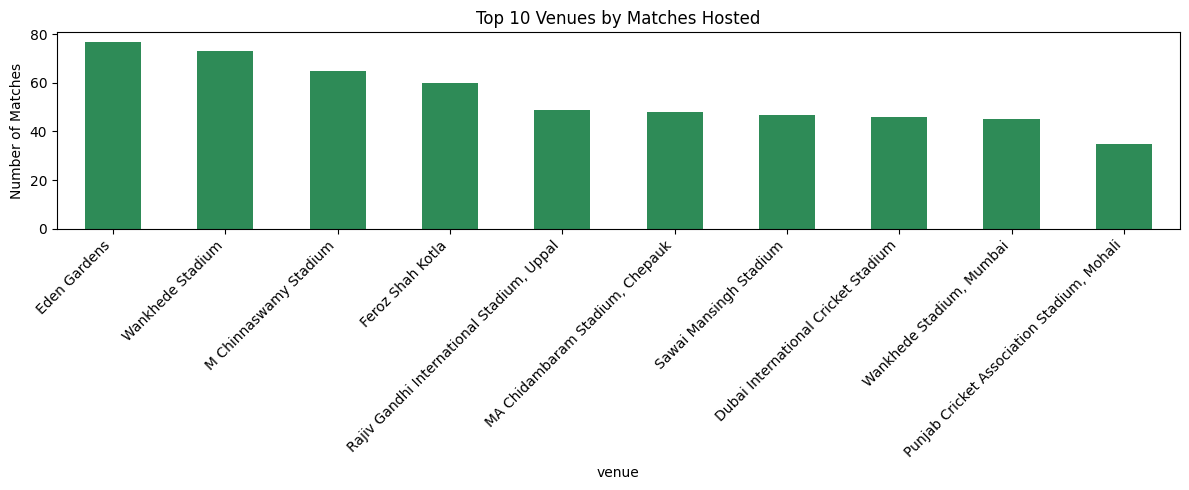

In [67]:
# ── 5. TOP VENUES ────────────────────────────────────────────
top_venues = matches['venue'].value_counts().head(10)

plt.figure(figsize=(12, 5))
top_venues.plot(kind='bar', color='seagreen')
plt.title('Top 10 Venues by Matches Hosted')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_venues.png')
plt.show()

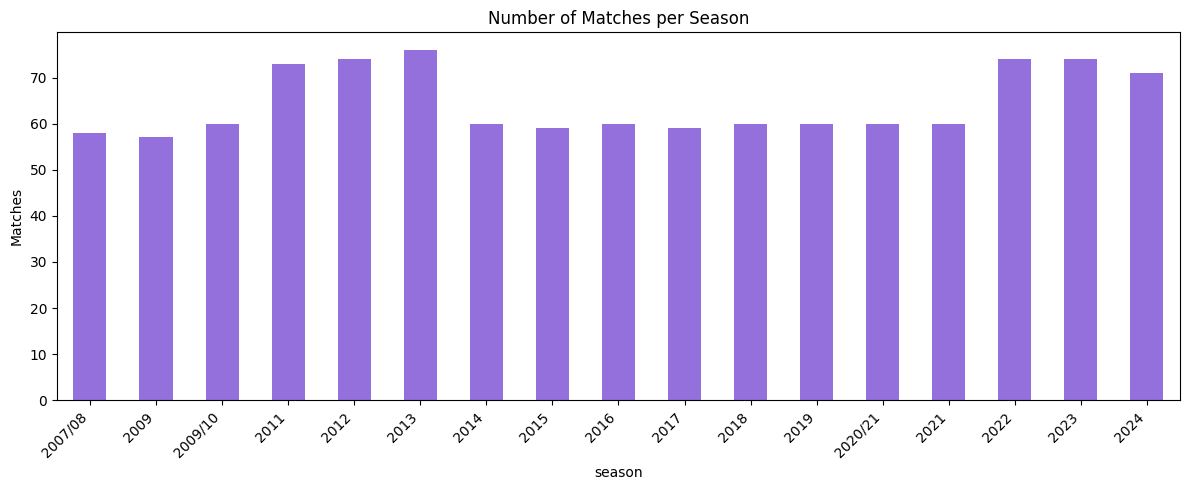

In [68]:
# ── 6. SEASON-WISE MATCHES ───────────────────────────────────
season_matches = matches['season'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
season_matches.plot(kind='bar', color='mediumpurple')
plt.title('Number of Matches per Season')
plt.ylabel('Matches')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('season_matches.png')
plt.show()

In [69]:
# ── 7. MAN OF THE MATCH ──────────────────────────────────────
top_mom = matches['player_of_match'].value_counts().head(10)
print("\nTop 10 Man of the Match winners:")
print(top_mom)


Top 10 Man of the Match winners:
player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
AD Russell        15
Name: count, dtype: int64


In [74]:
from sqlalchemy import create_engine

# MySQL connection
username = "praj_1024"
password = "191817"
host = "localhost"
port = "3306"
database = "ipl_match_analysis"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "matches"   # choose any table name
matches.to_sql(table_name, engine, if_exists="replace", index=False)

table_name = "deliveries"   # choose any table name
deliveries.to_sql(table_name, engine, if_exists="replace", index=False)

# Read back sample
pd.read_sql("SELECT * FROM matches LIMIT 5;", engine)
pd.read_sql("SELECT * FROM deliveries LIMIT 5;", engine)

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,None,None,None
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,None,0,None,None,None
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,None,None,None
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,None,0,None,None,None
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,None,0,None,None,None


In [75]:
pd.read_sql("SHOW TABLES;", engine)

,Tables_in_ipl_match_analysis
0,deliveries
1,matches


In [76]:
# ── 1. TOTAL MATCHES PER SEASON ──────────────────────────────
pd.read_sql("""
    SELECT season, COUNT(*) AS total_matches
    FROM matches
    GROUP BY season
    ORDER BY season;
""", engine)

,season,total_matches
0,2007/08,58
1,2009,57
2,2009/10,60
3,2011,73
4,2012,74
5,2013,76
6,2014,60
7,2015,59
8,2016,60
9,2017,59


In [77]:
# ── 2. TEAM WIN PERCENTAGE ───────────────────────────────────
pd.read_sql("""
    SELECT winner, COUNT(*) AS wins
    FROM matches
    WHERE winner IS NOT NULL
    GROUP BY winner
    ORDER BY wins DESC
    LIMIT 10;
""", engine)

,winner,wins
0,Mumbai Indians,144
1,Chennai Super Kings,138
2,Kolkata Knight Riders,131
3,Royal Challengers Bangalore,116
4,Rajasthan Royals,112
5,Kings XI Punjab,88
6,Sunrisers Hyderabad,88
7,Delhi Daredevils,67
8,Delhi Capitals,48
9,Deccan Chargers,29


In [78]:
# ── 3. TOSS DECISION IMPACT ──────────────────────────────────
pd.read_sql("""
    SELECT toss_decision,
           COUNT(*) AS total,
           SUM(CASE WHEN toss_winner = winner THEN 1 ELSE 0 END) AS toss_won_match,
           ROUND(SUM(CASE WHEN toss_winner = winner THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS win_pct
    FROM matches
    GROUP BY toss_decision;
""", engine)

,toss_decision,total,toss_won_match,win_pct
0,field,704,377.0,53.55
1,bat,391,177.0,45.27


In [79]:
# ── 4. TOP 10 BATSMEN BY RUNS ────────────────────────────────
pd.read_sql("""
    SELECT batter, SUM(batsman_runs) AS total_runs
    FROM deliveries
    GROUP BY batter
    ORDER BY total_runs DESC
    LIMIT 10;
""", engine)

,batter,total_runs
0,V Kohli,8014.0
1,S Dhawan,6769.0
2,RG Sharma,6630.0
3,DA Warner,6567.0
4,SK Raina,5536.0
5,MS Dhoni,5243.0
6,AB de Villiers,5181.0
7,CH Gayle,4997.0
8,RV Uthappa,4954.0
9,KD Karthik,4843.0


In [80]:
# ── 5. TOP 10 BOWLERS BY WICKETS ─────────────────────────────
pd.read_sql("""
    SELECT bowler, COUNT(*) AS total_wickets
    FROM deliveries
    WHERE is_wicket = 1
    AND dismissal_kind NOT IN ('run out', 'retired hurt', 'obstructing the field')
    GROUP BY bowler
    ORDER BY total_wickets DESC
    LIMIT 10;
""", engine)

,bowler,total_wickets
0,YS Chahal,205
1,PP Chawla,192
2,DJ Bravo,183
3,B Kumar,181
4,R Ashwin,180
5,SP Narine,180
6,A Mishra,174
7,SL Malinga,170
8,JJ Bumrah,168
9,RA Jadeja,160


In [81]:
# ── 6. TOP 10 VENUES BY MATCHES HOSTED ──────────────────────
pd.read_sql("""
    SELECT venue, COUNT(*) AS matches_hosted
    FROM matches
    GROUP BY venue
    ORDER BY matches_hosted DESC
    LIMIT 10;
""", engine)

,venue,matches_hosted
0,Eden Gardens,77
1,Wankhede Stadium,73
2,M Chinnaswamy Stadium,65
3,Feroz Shah Kotla,60
4,"Rajiv Gandhi International Stadium, Uppal",49
5,"MA Chidambaram Stadium, Chepauk",48
6,Sawai Mansingh Stadium,47
7,Dubai International Cricket Stadium,46
8,"Wankhede Stadium, Mumbai",45
9,"Punjab Cricket Association Stadium, Mohali",35


In [82]:
# ── 7. TOP MAN OF THE MATCH WINNERS ──────────────────────────
pd.read_sql("""
    SELECT player_of_match, COUNT(*) AS awards
    FROM matches
    WHERE player_of_match IS NOT NULL
    GROUP BY player_of_match
    ORDER BY awards DESC
    LIMIT 10;
""", engine)

,player_of_match,awards
0,AB de Villiers,25
1,CH Gayle,22
2,RG Sharma,19
3,DA Warner,18
4,V Kohli,18
5,MS Dhoni,17
6,RA Jadeja,16
7,SR Watson,16
8,YK Pathan,16
9,SP Narine,15


In [83]:
# ── 8. HIGHEST TEAM SCORES IN A MATCH ────────────────────────
pd.read_sql("""
    SELECT match_id, batting_team, SUM(total_runs) AS total_score
    FROM deliveries
    WHERE inning = 1
    GROUP BY match_id, batting_team
    ORDER BY total_score DESC
    LIMIT 10;
""", engine)

,match_id,batting_team,total_score
0,1426268,Sunrisers Hyderabad,287.0
1,1422126,Sunrisers Hyderabad,277.0
2,1422134,Kolkata Knight Riders,272.0
3,1426273,Sunrisers Hyderabad,266.0
4,598027,Royal Challengers Bangalore,263.0
5,1426280,Kolkata Knight Riders,261.0
6,1426281,Delhi Capitals,257.0
7,1359512,Lucknow Super Giants,257.0
8,980987,Royal Challengers Bangalore,248.0
9,419137,Chennai Super Kings,246.0


In [84]:
# ── 9. MOST SIXES HIT BY A BATSMAN ───────────────────────────
pd.read_sql("""
    SELECT batter, COUNT(*) AS total_sixes
    FROM deliveries
    WHERE batsman_runs = 6
    GROUP BY batter
    ORDER BY total_sixes DESC
    LIMIT 10;
""", engine)

,batter,total_sixes
0,CH Gayle,359
1,RG Sharma,281
2,V Kohli,273
3,AB de Villiers,253
4,MS Dhoni,252
5,DA Warner,236
6,KA Pollard,224
7,AD Russell,209
8,SV Samson,206
9,SK Raina,204


In [85]:
# ── 10. MOST FOURS HIT BY A BATSMAN ──────────────────────────
pd.read_sql("""
    SELECT batter, COUNT(*) AS total_fours
    FROM deliveries
    WHERE batsman_runs = 4
    GROUP BY batter
    ORDER BY total_fours DESC
    LIMIT 10;
""", engine)

,batter,total_fours
0,S Dhawan,768
1,V Kohli,708
2,DA Warner,663
3,RG Sharma,599
4,SK Raina,506
5,G Gambhir,492
6,RV Uthappa,481
7,AM Rahane,479
8,KD Karthik,466
9,F du Plessis,422


In [86]:
# ── 11. AVERAGE SCORE PER SEASON ─────────────────────────────
pd.read_sql("""
    SELECT m.season,
           ROUND(AVG(d.total_runs), 2) AS avg_runs_per_ball,
           ROUND(SUM(d.total_runs) / COUNT(DISTINCT d.match_id), 2) AS avg_score_per_match
    FROM deliveries d
    JOIN matches m ON d.match_id = m.id
    GROUP BY m.season
    ORDER BY m.season;
""", engine)

,season,avg_runs_per_ball,avg_score_per_match
0,2007/08,1.33,309.26
1,2009,1.20,286.89
2,2009/10,1.30,314.72
3,2011,1.24,289.78
4,2012,1.26,303.42
5,2013,1.24,297.39
6,2014,1.32,315.52
7,2015,1.34,311.07
8,2016,1.34,314.37
9,2017,1.36,318.41


In [87]:
# ── 12. WIN % BY BATTING OR FIELDING FIRST ───────────────────
pd.read_sql("""
    SELECT toss_decision,
           COUNT(*) AS total_matches,
           SUM(CASE WHEN toss_winner = winner THEN 1 ELSE 0 END) AS wins,
           ROUND(SUM(CASE WHEN toss_winner = winner THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS win_pct
    FROM matches
    WHERE result = 'runs' OR result = 'wickets'
    GROUP BY toss_decision;
""", engine)

,toss_decision,total_matches,wins,win_pct
0,field,692,374.0,54.05
1,bat,384,174.0,45.31


In [90]:
# ── 13. MOST ECONOMICAL BOWLERS (MIN 20 OVERS) ───────────────
pd.read_sql("""
    SELECT bowler,
           ROUND(SUM(total_runs) * 1.0 / COUNT(*) * 6, 2) AS economy,
           COUNT(*) AS balls_bowled
    FROM deliveries
    WHERE extras_type != 'wides' OR extras_type IS NULL
    GROUP BY bowler
    HAVING balls_bowled >= 120
    ORDER BY economy ASC
    LIMIT 10;
""", engine)

,bowler,economy,balls_bowled
0,Sohail Tanvir,6.19,248
1,A Chandila,6.28,234
2,FH Edwards,6.43,141
3,SMSM Senanayake,6.50,192
4,A Kumble,6.58,970
5,SM Pollock,6.59,276
6,M Muralitharan,6.68,1530
7,GD McGrath,6.68,325
8,IS Sodhi,6.73,181
9,SP Narine,6.74,4085


In [91]:
# ── 14. PLAYER WITH MOST WINS AS CAPTAIN (PROXY: MOST MOM) ───
pd.read_sql("""
    SELECT player_of_match, COUNT(*) AS mom_awards
    FROM matches
    GROUP BY player_of_match
    ORDER BY mom_awards DESC
    LIMIT 10;
""", engine)

,player_of_match,mom_awards
0,AB de Villiers,25
1,CH Gayle,22
2,RG Sharma,19
3,V Kohli,18
4,DA Warner,18
5,MS Dhoni,17
6,SR Watson,16
7,YK Pathan,16
8,RA Jadeja,16
9,AD Russell,15


In [92]:
# ── 15. SEASON-WISE TOP RUN SCORER (WINDOW FUNCTION) ─────────
pd.read_sql("""
    SELECT season, batter, total_runs
    FROM (
        SELECT m.season, d.batter,
               SUM(d.batsman_runs) AS total_runs,
               RANK() OVER (PARTITION BY m.season ORDER BY SUM(d.batsman_runs) DESC) AS rnk
        FROM deliveries d
        JOIN matches m ON d.match_id = m.id
        GROUP BY m.season, d.batter
    ) ranked
    WHERE rnk = 1
    ORDER BY season;
""", engine)

,season,batter,total_runs
0,2007/08,SE Marsh,616.0
1,2009,ML Hayden,572.0
2,2009/10,SR Tendulkar,618.0
3,2011,CH Gayle,608.0
4,2012,CH Gayle,733.0
5,2013,MEK Hussey,733.0
6,2014,RV Uthappa,660.0
7,2015,DA Warner,562.0
8,2016,V Kohli,973.0
9,2017,DA Warner,641.0


In [93]:
# ── 16. SEASON-WISE TOP WICKET TAKER (WINDOW FUNCTION) ───────
pd.read_sql("""
    SELECT season, bowler, total_wickets
    FROM (
        SELECT m.season, d.bowler,
               COUNT(*) AS total_wickets,
               RANK() OVER (PARTITION BY m.season ORDER BY COUNT(*) DESC) AS rnk
        FROM deliveries d
        JOIN matches m ON d.match_id = m.id
        WHERE d.is_wicket = 1
        GROUP BY m.season, d.bowler
    ) ranked
    WHERE rnk = 1
    ORDER BY season;
""", engine)

,season,bowler,total_wickets
0,2007/08,Sohail Tanvir,24
1,2009,RP Singh,26
2,2009/10,PP Ojha,22
3,2011,SL Malinga,30
4,2012,M Morkel,30
5,2013,DJ Bravo,34
6,2014,MM Sharma,26
7,2015,DJ Bravo,28
8,2016,B Kumar,24
9,2017,B Kumar,28
